In [1]:
# Cell 1: Import necessary libraries and define the dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # For potentially nicer data handling, though numpy arrays are fine

print("Libraries imported successfully.")

# Define the dataset
# Each tuple is (feature1, feature2, label)
# We'll store it as a NumPy array for easier slicing
data = np.array([
    [-1.0, 0.0, +1],   # X_1
    [-0.5, 0.5, +1],   # X_2
    [0.0, 1.0, -1],    # X_3
    [0.5, 1.0, -1],    # X_4
    [1.0, 0.0, +1],    # X_5
    [1.0, -1.0, +1],   # X_6
    [0.0, -1.0, -1],   # X_7
    [0.0, 0.0, -1]     # X_8
])

# Separate features (X) and labels (y)
X = data[:, :2]  # First two columns are features
y = data[:, 2]   # Last column is the label

# Number of data points
N = X.shape[0]
print(f"Number of data points (N): {N}")
print(f"Features (X):\n{X}")
print(f"Labels (y):\n{y}")

Libraries imported successfully.
Number of data points (N): 8
Features (X):
[[-1.   0. ]
 [-0.5  0.5]
 [ 0.   1. ]
 [ 0.5  1. ]
 [ 1.   0. ]
 [ 1.  -1. ]
 [ 0.  -1. ]
 [ 0.   0. ]]
Labels (y):
[ 1.  1. -1. -1.  1.  1. -1. -1.]


In [2]:
# Cell 2: Import necessary libraries and Set Matplotlib text rendering preferences
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # For potentially nicer data handling, though numpy arrays are fine

# --- Add this line to explicitly disable LaTeX rendering for text ---
plt.rcParams['text.usetex'] = False
# ------------------------------------------------------------------

print("Libraries imported successfully.")

# Define the dataset
# Each tuple is (feature1, feature2, label)
# We'll store it as a NumPy array for easier slicing
data = np.array([
    [-1.0, 0.0, +1],   # X_1
    [-0.5, 0.5, +1],   # X_2
    [0.0, 1.0, -1],    # X_3
    [0.5, 1.0, -1],    # X_4
    [1.0, 0.0, +1],    # X_5
    [1.0, -1.0, +1],   # X_6
    [0.0, -1.0, -1],   # X_7
    [0.0, 0.0, -1]     # X_8
])

# Separate features (X) and labels (y)
X = data[:, :2]  # First two columns are features
y = data[:, 2]   # Last column is the label

# Number of data points
N = X.shape[0]
print(f"Number of data points (N): {N}")
print(f"Features (X):\n{X}")
print(f"Labels (y):\n{y}")

Libraries imported successfully.
Number of data points (N): 8
Features (X):
[[-1.   0. ]
 [-0.5  0.5]
 [ 0.   1. ]
 [ 0.5  1. ]
 [ 1.   0. ]
 [ 1.  -1. ]
 [ 0.  -1. ]
 [ 0.   0. ]]
Labels (y):
[ 1.  1. -1. -1.  1.  1. -1. -1.]


In [3]:
# Cell 3: Implement the Decision Stump (Weak Learner)
# A decision stump is a one-level decision tree.
# It classifies based on a single feature and a single threshold.
# The decision rule can be:
# - if feature_j <= threshold then -1 else +1
# - if feature_j > threshold then -1 else +1

def train_decision_stump(X, y, D):
    """
    Trains a decision stump (weak learner) by finding the best feature, threshold,
    and polarity that minimizes the weighted error.

    Args:
        X (np.ndarray): Features (N_samples, N_features).
        y (np.ndarray): True labels (N_samples,).
        D (np.ndarray): Current weights of the data points (N_samples,).

    Returns:
        tuple: (best_feature_idx, best_threshold, best_polarity, min_weighted_error, predictions)
               - best_feature_idx (int): Index of the feature used for splitting.
               - best_threshold (float): Threshold value for the split.
               - best_polarity (int): +1 if (feature > threshold) then +1 else -1; -1 if (feature <= threshold) then +1 else -1.
               - min_weighted_error (float): Minimum weighted error achieved by this stump.
               - predictions (np.ndarray): Predictions made by the best stump.
    """
    N_samples, N_features = X.shape
    min_weighted_error = float('inf')
    best_stump = None
    best_predictions = None

    # Iterate over each feature
    for feature_idx in range(N_features):
        feature_values = X[:, feature_idx]
        # Get unique sorted values to consider as thresholds
        # Thresholds are typically midway between sorted unique values
        sorted_unique_values = np.sort(np.unique(feature_values))
        threshold_candidates = (sorted_unique_values[:-1] + sorted_unique_values[1:]) / 2
        # Also consider thresholds just outside the range of values for edge cases
        if len(sorted_unique_values) > 0:
            threshold_candidates = np.insert(threshold_candidates, 0, sorted_unique_values[0] - 0.1)
            threshold_candidates = np.append(threshold_candidates, sorted_unique_values[-1] + 0.1)

        # Iterate over each threshold candidate
        for threshold in threshold_candidates:
            # Test two polarities:
            # Polarity +1: if feature_j > threshold then +1 else -1
            # Polarity -1: if feature_j <= threshold then +1 else -1 (inverted)

            for polarity in [1, -1]:
                if polarity == 1: # Rule: if feature_j > threshold then +1 else -1
                    predictions = np.where(feature_values > threshold, 1, -1)
                else: # Rule: if feature_j <= threshold then +1 else -1 (i.e., if feature_j > threshold then -1 else +1)
                    predictions = np.where(feature_values <= threshold, 1, -1)

                # Calculate weighted error
                # Error = sum of weights of misclassified points
                misclassified = (predictions != y)
                weighted_error = np.sum(D[misclassified])

                if weighted_error < min_weighted_error:
                    min_weighted_error = weighted_error
                    best_stump = (feature_idx, threshold, polarity)
                    best_predictions = predictions

    return (*best_stump, min_weighted_error, best_predictions)

print("Decision stump training function defined.")

Decision stump training function defined.


In [4]:
# Cell 4: Implement AdaBoost Algorithm for T=3 iterations

# Initialize weights D_1
D = np.full(N, 1/N)
print(f"Initial weights D_1 (sum: {np.sum(D)}):\n{D}\n")

# Store results for each iteration
stumps = []
alphas = []
history = [] # To store epsilon, alpha, Z, D_next

# Total number of iterations
T = 3

for t in range(T):
    print(f"\n--- Iteration {t+1} ---")

    # 1. Train weak learner (decision stump)
    feature_idx, threshold, polarity, epsilon_t, predictions_t = train_decision_stump(X, y, D)
    stumps.append((feature_idx, threshold, polarity))

    print(f"  Weak Learner h_{t+1}: Feature {feature_idx+1}, Threshold {threshold:.2f}, Polarity {polarity}")
    print(f"  Predictions h_{t+1}(x):\n{predictions_t}")

    # 2. Compute weighted error epsilon_t
    print(f"  Weighted Error (epsilon_{t+1}): {epsilon_t:.4f}")

    # Ensure epsilon_t is not 0 or 1 for log calculation
    if epsilon_t == 0:
        print("  Warning: epsilon_t is 0. Setting alpha_t to a very large number.")
        alpha_t = 1000 # Effectively infinite
    elif epsilon_t == 1:
        print("  Warning: epsilon_t is 1. Setting alpha_t to a very small (negative) number.")
        alpha_t = -1000 # Effectively negative infinite
    else:
        # 3. Compute alpha_t
        alpha_t = 0.5 * np.log((1 - epsilon_t) / epsilon_t)
    alphas.append(alpha_t)
    print(f"  Weight of weak learner (alpha_{t+1}): {alpha_t:.4f}")

    # 4. Update weights D_{t+1}
    # For correctly classified points, D_i = D_i * exp(-alpha_t)
    # For misclassified points, D_i = D_i * exp(alpha_t)
    # This can be written as D_i = D_i * exp(-alpha_t * y_i * h_t(x_i))
    misclassified_mask = (predictions_t != y)
    correctly_classified_mask = ~misclassified_mask

    # Apply updates
    D_next = np.copy(D)
    D_next[correctly_classified_mask] *= np.exp(-alpha_t)
    D_next[misclassified_mask] *= np.exp(alpha_t)

    # 5. Normalize D_{t+1} by Z_t
    Z_t = np.sum(D_next)
    D = D_next / Z_t

    print(f"  Normalization Factor (Z_{t+1}): {Z_t:.4f}")
    print(f"  New weights D_{t+1} (sum: {np.sum(D)}):\n{D}\n")

    # Store history for later use
    history.append({
        'epsilon': epsilon_t,
        'alpha': alpha_t,
        'Z': Z_t,
        'D': np.copy(D), # Store a copy of the updated weights
        'stump': (feature_idx, threshold, polarity),
        'predictions': predictions_t
    })

print("\nAdaBoost iterations complete.")
print("\n--- Summary of Weak Learners ---")
for i, (f_idx, th, pol) in enumerate(stumps):
    print(f"h_{i+1}: Feature {f_idx+1}, Threshold {th:.2f}, Polarity {pol}, Alpha {alphas[i]:.4f}")

Initial weights D_1 (sum: 1.0):
[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


--- Iteration 1 ---
  Weak Learner h_1: Feature 1, Threshold -0.25, Polarity -1
  Predictions h_1(x):
[ 1  1 -1 -1 -1 -1 -1 -1]
  Weighted Error (epsilon_1): 0.2500
  Weight of weak learner (alpha_1): 0.5493
  Normalization Factor (Z_1): 0.8660
  New weights D_1 (sum: 1.0):
[0.08333333 0.08333333 0.08333333 0.08333333 0.25       0.25
 0.08333333 0.08333333]


--- Iteration 2 ---
  Weak Learner h_2: Feature 1, Threshold 0.75, Polarity 1
  Predictions h_2(x):
[-1 -1 -1 -1  1  1 -1 -1]
  Weighted Error (epsilon_2): 0.1667
  Weight of weak learner (alpha_2): 0.8047
  Normalization Factor (Z_2): 0.7454
  New weights D_2 (sum: 0.9999999999999999):
[0.25 0.25 0.05 0.05 0.15 0.15 0.05 0.05]


--- Iteration 3 ---
  Weak Learner h_3: Feature 2, Threshold 0.75, Polarity -1
  Predictions h_3(x):
[ 1  1 -1 -1  1  1  1  1]
  Weighted Error (epsilon_3): 0.1000
  Weight of weak learner (alpha_3): 1.0986
  Normalization

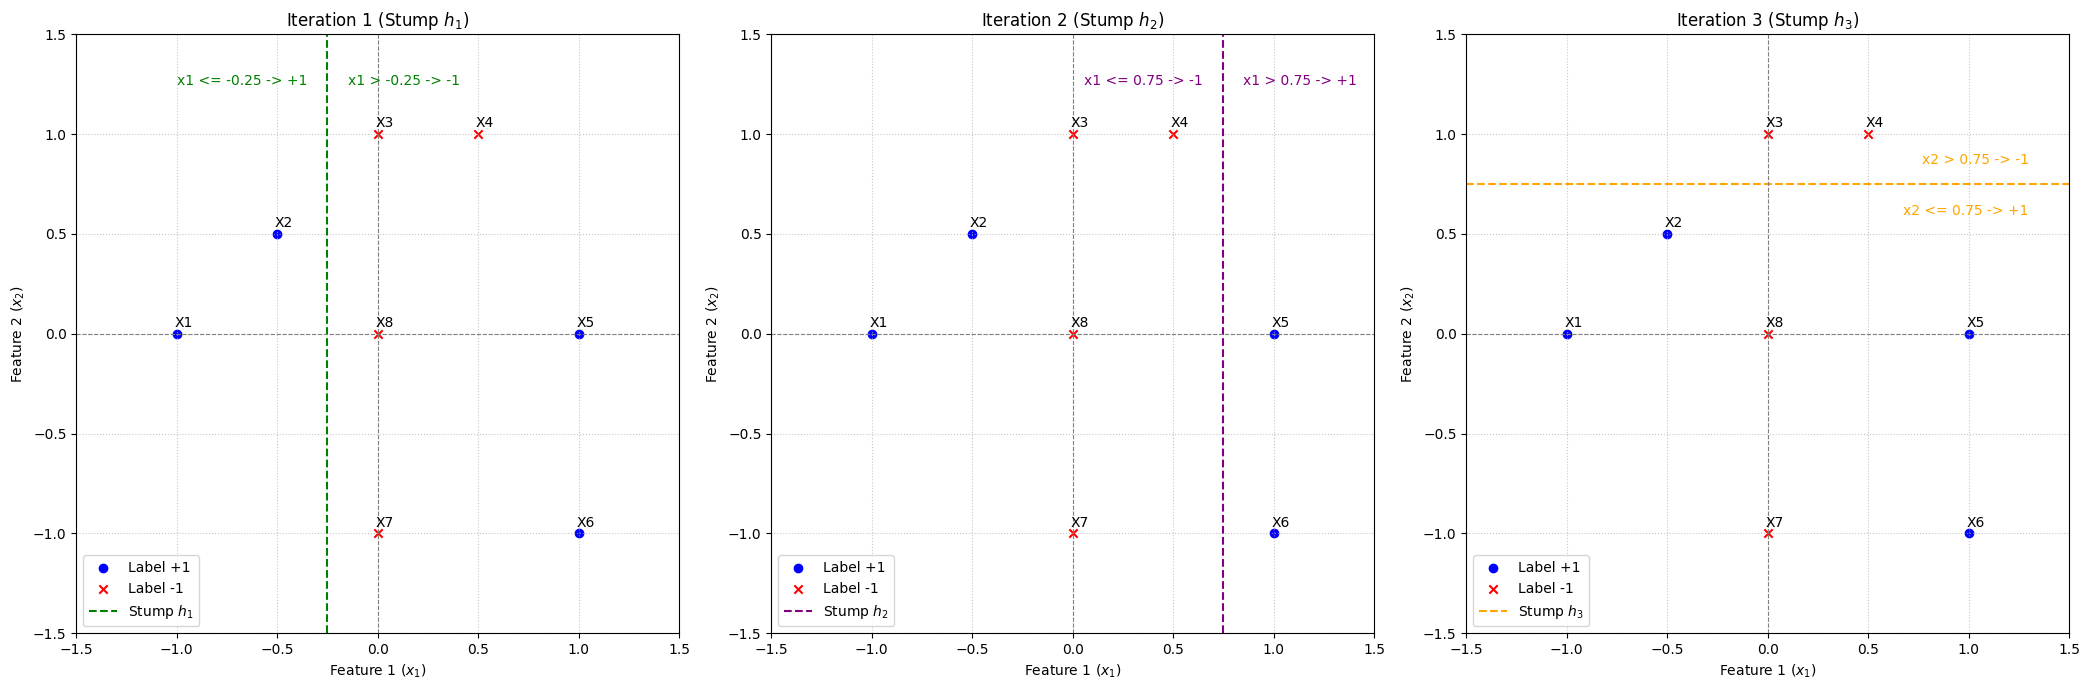

Individual decision stumps plotted.


In [5]:
# Cell 5: Visualize Decision Stumps and Final Classifier
def plot_decision_stump(ax, feature_idx, threshold, polarity, color, label):
    """Plots a decision stump on the given axes."""
    if feature_idx == 0: # Split on x1 (vertical line)
        line_start = -1.5
        line_end = 1.5
        ax.plot([threshold, threshold], [line_start, line_end], color=color, linestyle='--', label=label)
        if polarity == 1: # Rule: if feature_j > threshold then +1 else -1
            # Changed from LaTeX math to plain text
            ax.text(threshold + 0.1, line_end - 0.2, f'x1 > {threshold:.2f} -> +1', color=color, va='top')
            ax.text(threshold - 0.1, line_end - 0.2, f'x1 <= {threshold:.2f} -> -1', color=color, ha='right', va='top')
        else: # Rule: if feature_j <= threshold then +1, else -1
            # Changed from LaTeX math to plain text
            ax.text(threshold + 0.1, line_end - 0.2, f'x1 > {threshold:.2f} -> -1', color=color, va='top')
            ax.text(threshold - 0.1, line_end - 0.2, f'x1 <= {threshold:.2f} -> +1', color=color, ha='right', va='top')
    else: # Split on x2 (horizontal line)
        line_start = -1.5
        line_end = 1.5
        ax.plot([line_start, line_end], [threshold, threshold], color=color, linestyle='--', label=label)
        if polarity == 1: # Rule: if feature_j > threshold then +1 else -1
            # Changed from LaTeX math to plain text
            ax.text(line_end - 0.2, threshold + 0.1, f'x2 > {threshold:.2f} -> +1', color=color, ha='right')
            ax.text(line_end - 0.2, threshold - 0.1, f'x2 <= {threshold:.2f} -> -1', color=color, ha='right', va='top')
        else: # Rule: if feature_j <= threshold then +1, else -1
            # Changed from LaTeX math to plain text
            ax.text(line_end - 0.2, threshold + 0.1, f'x2 > {threshold:.2f} -> -1', color=color, ha='right')
            ax.text(line_end - 0.2, threshold - 0.1, f'x2 <= {threshold:.2f} -> +1', color=color, ha='right', va='top')

# Plot individual stumps
colors = ['green', 'purple', 'orange']
fig, axs = plt.subplots(1, T, figsize=(7*T, 7))

for t in range(T):
    ax = axs[t]
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', label='Label +1')
    ax.scatter(X[y == -1, 0], X[y == -1, 1], color='red', marker='x', label='Label -1')

    # Add annotations for each data point
    for i in range(N):
        ax.annotate(f'X{i+1}', (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

    feature_idx, threshold, polarity = history[t]['stump']
    plot_decision_stump(ax, feature_idx, threshold, polarity, colors[t], f'Stump $h_{t+1}$') # Keep label as math
    ax.set_title(f'Iteration {t+1} (Stump $h_{t+1}$)') # Keep title as math
    ax.set_xlabel('Feature 1 ($x_1$)') # Keep xlabel as math
    ax.set_ylabel('Feature 2 ($x_2$)') # Keep ylabel as math
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='lower left')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

print("Individual decision stumps plotted.")


Final AdaBoost Classifier Predictions H(x):
[ 1.  1. -1. -1.  1.  1. -1. -1.]
True Labels:
[ 1.  1. -1. -1.  1.  1. -1. -1.]

Training Error of AdaBoost: 0.0000


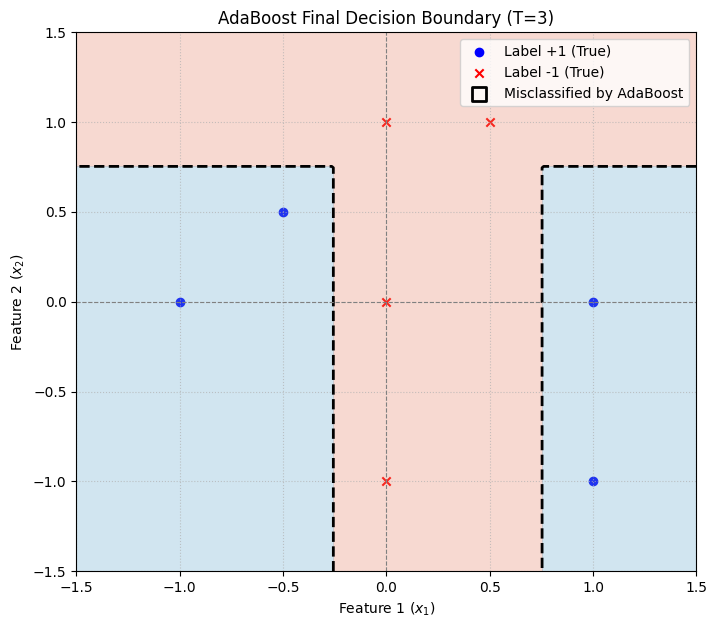


Final AdaBoost decision boundary plotted.


In [6]:
# Cell 6: Calculate and Plot Final Combined Classifier Decision Boundary and Training Error

# Calculate combined classifier H(x) = sign(sum(alpha_t * h_t(x)))
def predict_adaboost(X, stumps, alphas):
    N_samples = X.shape[0]
    final_predictions = np.zeros(N_samples)
    for t in range(len(stumps)):
        feature_idx, threshold, polarity = stumps[t]
        alpha = alphas[t]
        if polarity == 1: # Rule: if feature_j > threshold then +1 else -1
            weak_predictions = np.where(X[:, feature_idx] > threshold, 1, -1)
        else: # Rule: if feature_j <= threshold then +1 else -1
            weak_predictions = np.where(X[:, feature_idx] <= threshold, 1, -1)
        final_predictions += alpha * weak_predictions
    return np.sign(final_predictions)

# Get predictions for training data
H_predictions = predict_adaboost(X, stumps, alphas)

# Calculate training error
training_error = np.sum(H_predictions != y) / N
print(f"\nFinal AdaBoost Classifier Predictions H(x):\n{H_predictions}")
print(f"True Labels:\n{y}")
print(f"\nTraining Error of AdaBoost: {training_error:.4f}")

# Plot the final decision boundary
plt.figure(figsize=(8, 7))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', label='Label +1 (True)')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', marker='x', label='Label -1 (True)')

# Plot misclassified points with a distinct marker
misclassified_X = X[H_predictions != y]
plt.scatter(misclassified_X[:, 0], misclassified_X[:, 1], color='black', marker='s', s=100, facecolors='none', edgecolors='black', linewidth=2, label='Misclassified by AdaBoost')

# Create a meshgrid to plot the decision boundary
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

Z = predict_adaboost(grid_points, stumps, alphas)
Z = Z.reshape(xx1.shape)

# Plot the decision boundary using contourf
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=plt.cm.RdBu, levels=[-1, 0, 1])
plt.contour(xx1, xx2, Z, colors='black', levels=[0], linewidths=2, linestyles='--')

plt.title('AdaBoost Final Decision Boundary (T=3)')
plt.xlabel('Feature 1 ($x_1$)')
plt.ylabel('Feature 2 ($x_2$)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.show()

print("\nFinal AdaBoost decision boundary plotted.")